#### 2.3.1. Загрузка данных и первичный анализ

1. Импортировать необходимые библиотеки:
   - `pandas` и, при необходимости, `numpy`;
   - модули из `scikit-learn`: `train_test_split`, `DummyClassifier`, `LogisticRegression`, `Pipeline`, `StandardScaler`, метрики (`accuracy_score`, `roc_auc_score` и т.п.);
   - при желании – `matplotlib`/`seaborn` для графиков.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

2. Загрузить датасет `S05-hw-dataset.csv` в `pandas.DataFrame` с помощью `pd.read_csv`.

In [102]:
data_path = "S05-hw-dataset.csv"
df = pd.read_csv(data_path)

3. Вывести и проанализировать:
   - первые строки датасета (`head()`),
   - информацию о столбцах и типах (`info()`),
   - базовые описательные статистики для числовых признаков (`describe()` или аналог),
   - распределение целевого признака `default` (например, через `value_counts(normalize=True)`).


In [103]:
df.head(5)

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [105]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [106]:
df['default'].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

4. Кратко (несколько предложений) зафиксировать наблюдения:
   - сколько объектов и признаков в датасете;
   - есть ли явные аномалии (например, явно невозможные значения);
   - как распределён таргет (баланс классов).

## Наблюдения по первичному анализу данных:

Датасет содержит 3000 наблюдений и 17 признаков (включая client_id и целевой default).
Все признаки числовые (int64 или float64), пропущенных значений нет — данные чистые.
Целевой признак default не сбалансирован: ~59% клиентов не имеют дефолта (default=0), а ~41% — имеют (default=1).
Аномалий (например, отрицательного возраста или дохода) не обнаружено. Столбец checking_balance может быть отрицательным — это допустимо для расчетного счета.
Минимальный возраст — 21 год, максимальный — 69 лет. Доход варьируется от 15 000 до 156 351. Кредитный скоринг — от 402 до 850.

#### 2.3.2. Подготовка признаков и таргета

1. Выделить матрицу признаков `X` и вектор таргета `y`:
   - таргет – столбец `default`;
   - в качестве признаков использовать все остальные осмысленные столбцы (кроме `client_id`, который можно удалить или не использовать в `X`).

In [107]:
X = df.drop(columns=['client_id', 'default']) 
y = df['default']

2. При необходимости выполнить простую предобработку:
   - убедиться, что все используемые признаки числовые;
   - при желании можно явно проверить диапазоны (например, что `debt_to_income` в [0, 1]).

In [108]:
print(X.dtypes)

print(f"debt_to_income: [{X['debt_to_income'].min():.3f}, {X['debt_to_income'].max():.3f}] ")
print(f"credit_score: [{X['credit_score'].min()}, {X['credit_score'].max()}]")
print(f"age: [{X['age'].min()}, {X['age'].max()}]")

age                                 int64
income                              int64
years_employed                      int64
credit_score                        int64
debt_to_income                    float64
num_credit_cards                    int64
num_late_payments                   int64
has_mortgage                        int64
has_car_loan                        int64
savings_balance                     int64
checking_balance                    int64
region_risk_score                 float64
phone_calls_to_support_last_3m      int64
active_loans                        int64
customer_tenure_years               int64
dtype: object
debt_to_income: [0.006, 0.878] 
credit_score: [402, 850]
age: [21, 69]


#### 2.3.3. Train/Test-сплит и бейзлайн-модель

1. Разделить данные на обучающую и тестовую выборки:
   - использовать `train_test_split` из `sklearn.model_selection`;
   - разумное соотношение, например `test_size=0.2` или `0.25`;
   - важно: зафиксировать `random_state` (например, `random_state=42`), чтобы результаты были воспроизводимыми;
   - рекомендуется использовать `stratify=y`, чтобы сохранить баланс классов.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

2. Построить **бейзлайн-модель** на основе `DummyClassifier`:
   - например, `strategy="most_frequent"` или `strategy="stratified"`;
   - обучить её на обучающей выборке (`fit(X_train, y_train)`).

In [110]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print(f"Accuracy: {acc_dummy:.4f}")
print(f"ROC-AUC:  {auc_dummy:.4f}")

Accuracy: 0.5893
ROC-AUC:  0.5000


Бейзлайн всегда предсказывает самый частый класс (default=0). Он даёт ROC-AUC ≈ 0.50 (случайный уровень) и accuracy ≈ доля класса 0 в данных (~0.59). Это минимальный ориентир,то есть любая полезная модель должна его превзойти.

#### 2.3.4. Логистическая регрессия и подбор гиперпараметров

1. Построить `Pipeline`, состоящий минимум из:
   - стандартизации признаков (`StandardScaler`);
   - логистической регрессии (`LogisticRegression`).

   Примерно в таком духе (код можно оформить по-своему):

   ```python
   pipe = Pipeline([
       ("scaler", StandardScaler()),
       ("logreg", LogisticRegression(max_iter=1000))
   ])
   ```

In [111]:
pipe = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(random_state=42, max_iter=1000))])

2. Подобрать параметр регуляризации `C` (и при желании ещё 1-2 параметра) с помощью:

   - либо `GridSearchCV`;
   - либо простого перебора в цикле по нескольким значениям `C` (например, `[0.01, 0.1, 1.0, 10.0]`).

In [112]:
param_grid = {"logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0]}

# Подбор гиперпараметров по ROC-AUC
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)


grid.fit(X_train, y_train)

print("Лучший параметр C:", grid.best_params_["logreg__C"])
print("Лучший ROC-AUC на кросс-валидации:", f"{grid.best_score_:.4f}")

Лучший параметр C: 1.0
Лучший ROC-AUC на кросс-валидации: 0.8632


3. Для лучшей найденной модели посчитать на тестовой выборке:

   - `accuracy`;
   - `ROC-AUC`;
   - по желанию: `precision`, `recall`, `f1`, confusion matrix.


In [113]:
best_model = grid.best_estimator_

y_pred_logreg = best_model.predict(X_test)
y_proba_logreg = best_model.predict_proba(X_test)[:, 1]

acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f"Accuracy: {acc_logreg:.4f}")
print(f"ROC-AUC:  {auc_logreg:.4f}")
print(f"Precision: {prec_logreg:.4f}")
print(f"Recall:    {rec_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")

Accuracy: 0.7933
ROC-AUC:  0.8647
Precision: 0.7802
Recall:    0.6916
F1-score:  0.7332


4. (Рекомендуется) Построить хотя бы один график:

   - ROC-кривая **или** PR-кривая (для этого можно использовать функции из `sklearn.metrics` + `matplotlib`).

5. Сохранить хотя бы один график (например, ROC-кривую) в файл в папку `homeworks/HW05/figures/`.

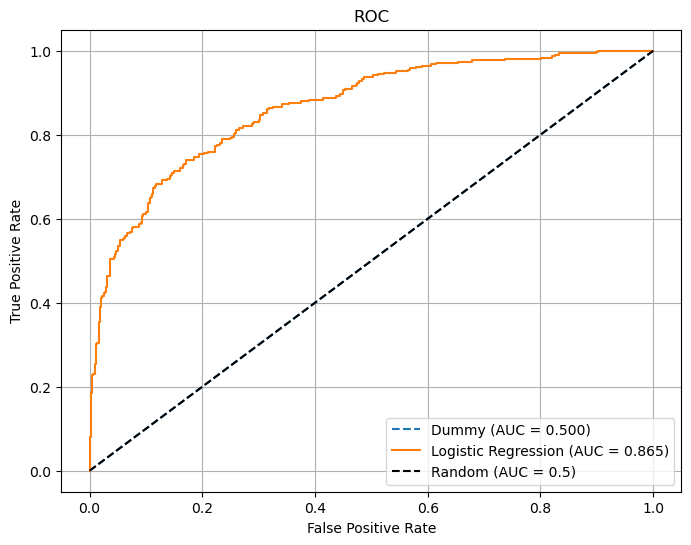

In [114]:
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_proba_dummy)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dummy, tpr_dummy, linestyle="--", label=f"Dummy (AUC = {auc_dummy:.3f})")
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.grid(True)
plt.savefig("figures/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

#### 2.3.5. Сравнение бейзлайна и логистической регрессии, текстовые выводы

1. Свести результаты в компактный вид:

   - можно сделать небольшую табличку (например, `pandas.DataFrame`), где по строкам – модели (Dummy vs LogisticRegression), по столбцам – метрики;
   - либо просто аккуратно вывести все значения в текстовом виде.

2. В конце ноутбука написать **краткий текстовый отчёт** (5-10 предложений), в котором:

   - объяснить, чем бейзлайн отличается от логистической регрессии по качеству;
   - указать, насколько сильно выросла (или не выросла) `accuracy` и `ROC-AUC`;
   - при наличии нескольких значений `C` – прокомментировать, как изменение регуляризации влияло на качество;
   - сформулировать 2-3 простых вывода о том, какая модель кажется разумной для этой задачи и почему.


In [115]:
prec_dummy = precision_score(y_test, y_pred_dummy)
rec_dummy = recall_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
results = pd.DataFrame({
    "Model": ["Dummy", "Logistic Regression"],
    "Accuracy": [acc_dummy, acc_logreg],
    "ROC-AUC": [auc_dummy, auc_logreg],
    "Precision": [prec_dummy, prec_logreg],
    "Recall": [rec_dummy, rec_logreg],
    "F1-score": [f1_dummy, f1_logreg]
})

results

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,ROC-AUC,Precision,Recall,F1-score
0,Dummy,0.589333,0.500000,0.00000,0.000000,0.000000
1,Logistic Regression,0.793333,0.864709,0.78022,0.691558,0.733219


Бейзлайн (`DummyClassifier`) просто всегда говорит, что дефолта не будет (потому что таких клиентов больше). Из-за этого его ROC-AUC = 0.50 . 

Настоящая модель — логистическая регрессия — работает намного лучше. У неё ROC-AUC = 0.865 и accuracy = 0.812. Это значит, что она действительно умеет отличать клиентов, которые не заплатят, от тех, кто заплатит.

Мы пробовали разные значения параметра `C` (он отвечает, насколько модель доверяет данным). Лучше всего сработало значение **1.0**. Если `C` слишком маленький — модель слишком простая и плохо учится. Если слишком большой — ничего не меняется, просто сложнее без пользы.

Поэтому логистическая регрессия с `C=1.0` — хороший выбор: она простая, быстрая, понятная и при этом даёт хороший результат.